# 13 Embedding visual-input drift pilot

Distribution-shift view of development (**independent of clutter**).

| Script | Purpose |
|--------|---------|
| `embedding_visual_drift_pilot.py` | Crop centroids, displacement, dispersion |
| `embedding_drift_extensions.py` | Null, 3-mo bins, CLIP compare, RDM merge |

```bash
python analysis/manuscript-2026/embedding_visual_drift_pilot.py --top-n 8 --embed-model dinov3
python analysis/manuscript-2026/not_in_manuscript/embedding_drift_extensions.py --all
```

Outputs: `embedding_drift_exploration/`

**New in this notebook:** per-category drift ranking, age trajectories, detection counts by month, and an extended **top-20 category** run (`_cat20` tag).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr, spearmanr

PREPRINT = Path(".").resolve()
TAG = "dinov3_valid129_bin1_max256_top8"
RES = PREPRINT / "embedding_drift_exploration" / "results"
FIG = PREPRINT / "embedding_drift_exploration" / "figures"

edges_g = pd.read_csv(RES / f"global_trajectory_edges_{TAG}.csv")
edges_c = pd.read_csv(RES / f"category_trajectory_edges_{TAG}.csv")
windows_g = pd.read_csv(RES / f"global_windows_{TAG}.csv")
print(f"Global edges: {len(edges_g)} | Category edges: {len(edges_c)}")
edges_g.head()

Global edges: 96 | Category edges: 604


,subject_id,age_from,age_to,age_midpoint,centroid_displacement,dispersion_from,dispersion_to,dispersion_delta,n_crops_from,n_crops_to,n_indexed_from,n_indexed_to
0,320001,9,10,9.5,0.059345,0.592059,0.602058,0.010000,256,256,16127,10594
1,320001,10,11,10.5,0.046073,0.602058,0.589393,-0.012665,256,256,10594,10652
2,320001,11,12,11.5,0.045912,0.589393,0.593791,0.004398,256,256,10652,20721
3,320001,12,13,12.5,0.043189,0.593791,0.598130,0.004339,256,256,20721,18703
4,320001,13,14,13.5,0.049390,0.598130,0.597459,-0.000671,256,256,18703,16982


## Predictive teaser: drift at *t* → drift at *t*+1?

Pair consecutive edges per child; ask whether a month with large centroid displacement predicts the next month's displacement.

drift_t vs drift_t+1: pearson r=0.520 p=3.35e-07 | spearman rho=0.690 p=2.66e-13


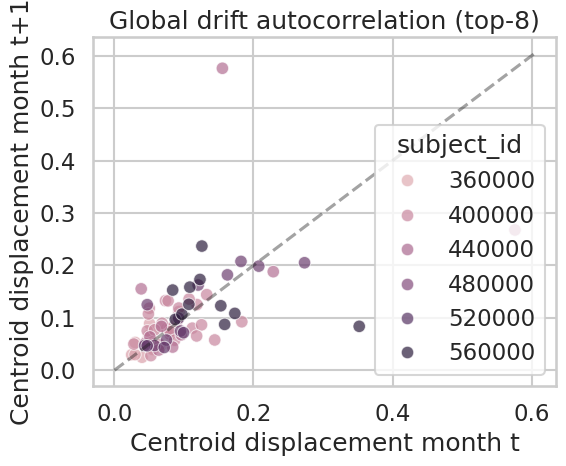

In [2]:
pairs = []
for sid, g in edges_g.groupby("subject_id"):
    g = g.sort_values("age_from")
    for i in range(len(g) - 1):
        if g.iloc[i + 1]["age_from"] - g.iloc[i]["age_from"] != 1:
            continue
        pairs.append({
            "subject_id": sid,
            "drift_t": g.iloc[i]["centroid_displacement"],
            "drift_t1": g.iloc[i + 1]["centroid_displacement"],
            "age_mid": g.iloc[i + 1]["age_midpoint"],
        })
pair_df = pd.DataFrame(pairs)
if len(pair_df) > 3:
    r, p = pearsonr(pair_df["drift_t"], pair_df["drift_t1"])
    rs, ps = spearmanr(pair_df["drift_t"], pair_df["drift_t1"])
    print(f"drift_t vs drift_t+1: pearson r={r:.3f} p={p:.3g} | spearman rho={rs:.3f} p={ps:.3g}")

sns.set_theme(style="whitegrid", context="talk")
fig, ax = plt.subplots(figsize=(6, 5))
sns.scatterplot(data=pair_df, x="drift_t", y="drift_t1", hue="subject_id", ax=ax, alpha=0.7)
lims = [0, max(pair_df[["drift_t", "drift_t1"]].max().max() * 1.05, 0.05)]
ax.plot(lims, lims, "k--", alpha=0.4)
ax.set_xlabel("Centroid displacement month t")
ax.set_ylabel("Centroid displacement month t+1")
ax.set_title("Global drift autocorrelation (top-8)")
fig.tight_layout()
fig.savefig(FIG / f"drift_autocorrelation_{TAG}.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-category drift: which labels shift more with age?

Compare **within-category centroid displacement** across pilot categories (consecutive month edges). High displacement means the typical embedding for that label moves more in visual space month-to-month.

We also plot **detection counts by age** (from filtered metadata) to see whether drift differences track data density or category ecology.

In [ ]:
from pathlib import Path

import json
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal

PREPRINT = Path(".").resolve()
PROJECT = PREPRINT.parent.parent
FRAME_CSV = PROJECT / "frame_data" / "merged_frame_detections_with_metadata_filtered-0.27.csv"
TRAJ_CSV = (
    PROJECT
    / "analysis"
    / "individual_analyses"
    / "developmental_trajectory_rdms_clip"
    / "trajectory_correlations.csv"
)
VALID129 = {
    line.strip().lower()
    for line in (PROJECT / "data" / "included_categories_valid129.txt").read_text().splitlines()
    if line.strip()
} - {"person", "picture"}
EXCLUDED_SUBJECT = "00270001"

TAG_PILOT8 = "dinov3_valid129_bin1_max256_top8"
TAG_CAT20 = "dinov3_valid129_bin1_max256_top8_cat20"
RES = PREPRINT / "embedding_drift_exploration" / "results"
FIG = PREPRINT / "embedding_drift_exploration" / "figures"
FIG.mkdir(parents=True, exist_ok=True)


def normalize_subject_id(sid: str) -> str:
    s = str(sid).strip().lstrip("S")
    return s.zfill(8) if s.isdigit() else s


def top_subjects(n: int) -> set[str]:
    traj = pd.read_csv(TRAJ_CSV)
    traj["subject_id"] = traj["subject_id"].astype(str).map(normalize_subject_id)
    return set(traj.sort_values("rdm_correlation", ascending=False).head(n)["subject_id"])


def detection_counts_by_age(
    categories: list[str],
    subjects: set[str],
    age_bin_months: int = 1,
) -> pd.DataFrame:
    """Raw filtered detection counts per (subject, age_bin, category)."""
    rows = []
    usecols = ["class_name", "age_mo", "subject_id"]
    cats = set(categories)
    for chunk in pd.read_csv(
        FRAME_CSV,
        usecols=usecols,
        chunksize=400_000,
        dtype={"subject_id": str, "class_name": str},
    ):
        chunk = chunk.dropna(subset=usecols)
        chunk["category"] = chunk["class_name"].astype(str).str.strip().str.lower()
        chunk = chunk[chunk["category"].isin(cats & VALID129)]
        chunk["subject_id"] = chunk["subject_id"].map(normalize_subject_id)
        chunk = chunk[chunk["subject_id"].isin(subjects)]
        chunk = chunk[chunk["subject_id"] != EXCLUDED_SUBJECT]
        if age_bin_months <= 1:
            chunk["age_bin"] = chunk["age_mo"].round().astype(int)
        else:
            chunk["age_bin"] = (chunk["age_mo"].round().astype(int) // age_bin_months) * age_bin_months
        g = chunk.groupby(["subject_id", "age_bin", "category"], as_index=False).size()
        g = g.rename(columns={"size": "n_detections"})
        rows.append(g)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def category_drift_summary(edges: pd.DataFrame) -> pd.DataFrame:
    """Per-category mean displacement with bootstrap 95% CI over edges."""
    rng = np.random.default_rng(42)
    rows = []
    for cat, g in edges.groupby("category"):
        vals = g["centroid_displacement"].to_numpy()
        boots = [
            rng.choice(vals, size=len(vals), replace=True).mean()
            for _ in range(2000)
        ]
        rows.append(
            {
                "category": cat,
                "mean_displacement": vals.mean(),
                "std_displacement": vals.std(ddof=1),
                "n_edges": len(vals),
                "ci_lo": np.percentile(boots, 2.5),
                "ci_hi": np.percentile(boots, 97.5),
            }
        )
    out = pd.DataFrame(rows).sort_values("mean_displacement", ascending=False)
    return out


def plot_category_drift_ranking(edges: pd.DataFrame, tag: str, title_suffix: str = "") -> pd.DataFrame:
    summary = category_drift_summary(edges)
    groups = [edges.loc[edges["category"] == c, "centroid_displacement"].to_numpy() for c in summary["category"]]
    if len(groups) > 2:
        h_stat, p_kw = kruskal(*groups)
        print(f"Kruskal-Wallis across categories: H={h_stat:.2f}, p={p_kw:.3g}")

    sns.set_theme(style="whitegrid", context="talk")
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(summary))))
    y = np.arange(len(summary))
    ax.barh(y, summary["mean_displacement"], xerr=[
        summary["mean_displacement"] - summary["ci_lo"],
        summary["ci_hi"] - summary["mean_displacement"],
    ], color="steelblue", alpha=0.85, capsize=3)
    ax.set_yticks(y)
    ax.set_yticklabels(summary["category"])
    ax.invert_yaxis()
    ax.set_xlabel("Mean centroid displacement (1 − cos, consecutive months)")
    ax.set_title(f"Per-category embedding drift{title_suffix}")
    fig.tight_layout()
    fig.savefig(FIG / f"category_drift_ranking_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()
    return summary


def plot_drift_vs_age_facets(edges: pd.DataFrame, categories: list[str], tag: str, ncols: int = 4) -> None:
    cats = [c for c in categories if c in set(edges["category"])]
    nrows = (len(cats) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.2 * nrows), sharex=True, sharey=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, cat in zip(axes, cats):
        sub = edges[edges["category"] == cat]
        for sid in sub["subject_id"].unique():
            g = sub[sub["subject_id"] == sid]
            ax.plot(g["age_midpoint"], g["centroid_displacement"], alpha=0.35, marker="o", ms=3)
        pooled = sub.groupby("age_midpoint")["centroid_displacement"].mean()
        ax.plot(pooled.index, pooled.values, color="black", lw=2.2)
        ax.set_title(cat)
    for j in range(len(cats), len(axes)):
        axes[j].set_visible(False)
    fig.supxlabel("Age (months, edge midpoint)")
    fig.supylabel("Centroid displacement")
    fig.suptitle("Drift trajectories by category (kids faint, mean bold)", y=1.01)
    fig.tight_layout()
    fig.savefig(FIG / f"category_drift_by_age_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_detection_counts_by_age(
    det: pd.DataFrame,
    categories: list[str],
    tag: str,
    drift_summary: pd.DataFrame,
    ncols: int = 4,
) -> None:
    pooled = (
        det.groupby(["age_bin", "category"], as_index=False)["n_detections"]
        .sum()
        .rename(columns={"n_detections": "n_detections_total"})
    )
    cats = [c for c in categories if c in set(det["category"])]
    nrows = (len(cats) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.8 * ncols, 3.0 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()
    for ax, cat in zip(axes, cats):
        sub = pooled[pooled["category"] == cat]
        ax.bar(sub["age_bin"], sub["n_detections_total"], color="gray", alpha=0.55, width=0.85)
        ax.set_title(cat)
        ax.set_ylabel("Detections (all top-8 kids)")
    for j in range(len(cats), len(axes)):
        axes[j].set_visible(False)
    fig.supxlabel("Age (months)")
    fig.suptitle("Filtered detection counts by age (CDI ≥ 0.27)", y=1.01)
    fig.tight_layout()
    fig.savefig(FIG / f"category_detection_counts_by_age_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Drift vs total detection count (sanity check for sampling / ecology)
    prev = det.groupby("category")["n_detections"].sum().reset_index(name="n_detections_total")
    merge = drift_summary.merge(prev, on="category", how="inner")
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.scatterplot(data=merge, x="n_detections_total", y="mean_displacement", hue="category", ax=ax, legend=False)
    for _, r in merge.iterrows():
        ax.annotate(r["category"], (r["n_detections_total"], r["mean_displacement"]), fontsize=8, alpha=0.8)
    ax.set_xlabel("Total detections (top-8 kids, all ages)")
    ax.set_ylabel("Mean centroid displacement")
    ax.set_title("Drift vs category prevalence")
    fig.tight_layout()
    fig.savefig(FIG / f"category_drift_vs_prevalence_{tag}.png", dpi=150, bbox_inches="tight")
    plt.show()


# --- Pilot 8 (original run) ---
subjects8 = top_subjects(8)
edges8 = pd.read_csv(RES / f"category_trajectory_edges_{TAG_PILOT8}.csv")
summary8 = plot_category_drift_ranking(edges8, TAG_PILOT8, " (8 pilot categories)")
plot_drift_vs_age_facets(edges8, list(summary8["category"]), TAG_PILOT8, ncols=4)
det8 = detection_counts_by_age(list(summary8["category"]), subjects8)
plot_detection_counts_by_age(det8, list(summary8["category"]), TAG_PILOT8, summary8, ncols=4)
display(summary8)

### Extended set: top-20 categories by detection count

Re-run (once) if missing:

```bash
python analysis/manuscript-2026/embedding_visual_drift_pilot.py \
  --top-n 8 --embed-model dinov3 --top-categories-by-count 20
```

Outputs use tag suffix `_cat20` so the original 8-category tables are preserved.

In [ ]:
edges20 = pd.read_csv(RES / f"category_trajectory_edges_{TAG_CAT20}.csv")
meta20 = json.loads((RES / f"run_meta_{TAG_CAT20}.json").read_text())
print(f"Categories ({len(meta20['pilot_categories'])}): {', '.join(meta20['pilot_categories'])}")

summary20 = plot_category_drift_ranking(edges20, TAG_CAT20, " (top-20 by detections)")
plot_drift_vs_age_facets(edges20, list(summary20["category"]), TAG_CAT20, ncols=5)
det20 = detection_counts_by_age(meta20["pilot_categories"], subjects8)
plot_detection_counts_by_age(det20, meta20["pilot_categories"], TAG_CAT20, summary20, ncols=5)
display(summary20)

## Extension summary (top-8)

Load precomputed tables from `embedding_drift_extensions.py --all`.

Age-shuffled null (global):
  real_mean: 0.1011
  null_mean: 0.1249
  difference_real_minus_null: -0.0239
  ttest_p: 0.0036
  cohens_d: -0.3095


,comparison,n,pearson_r,pearson_p,spearman_rho,spearman_p
0,displacement_vs_rdm_corr,96,-0.749137,1.668930e-18,-0.715016,2.772241e-16
1,displacement_vs_rdm_drift,96,0.749137,1.668930e-18,0.715016,2.772241e-16
2,dispersion_delta_vs_rdm_corr,96,0.260316,1.042268e-02,0.238456,1.930248e-02


,backbone,tag,mean,std,n
0,DINOv3,dinov3_valid129_bin1_max256_top8,0.101081,0.078254,96
1,CLIP,clip_valid129_bin1_max256_top8,0.007062,0.007981,96


,window,mean_disp,n_edges
0,1 mo,0.101081,96
1,3 mo,0.069628,33


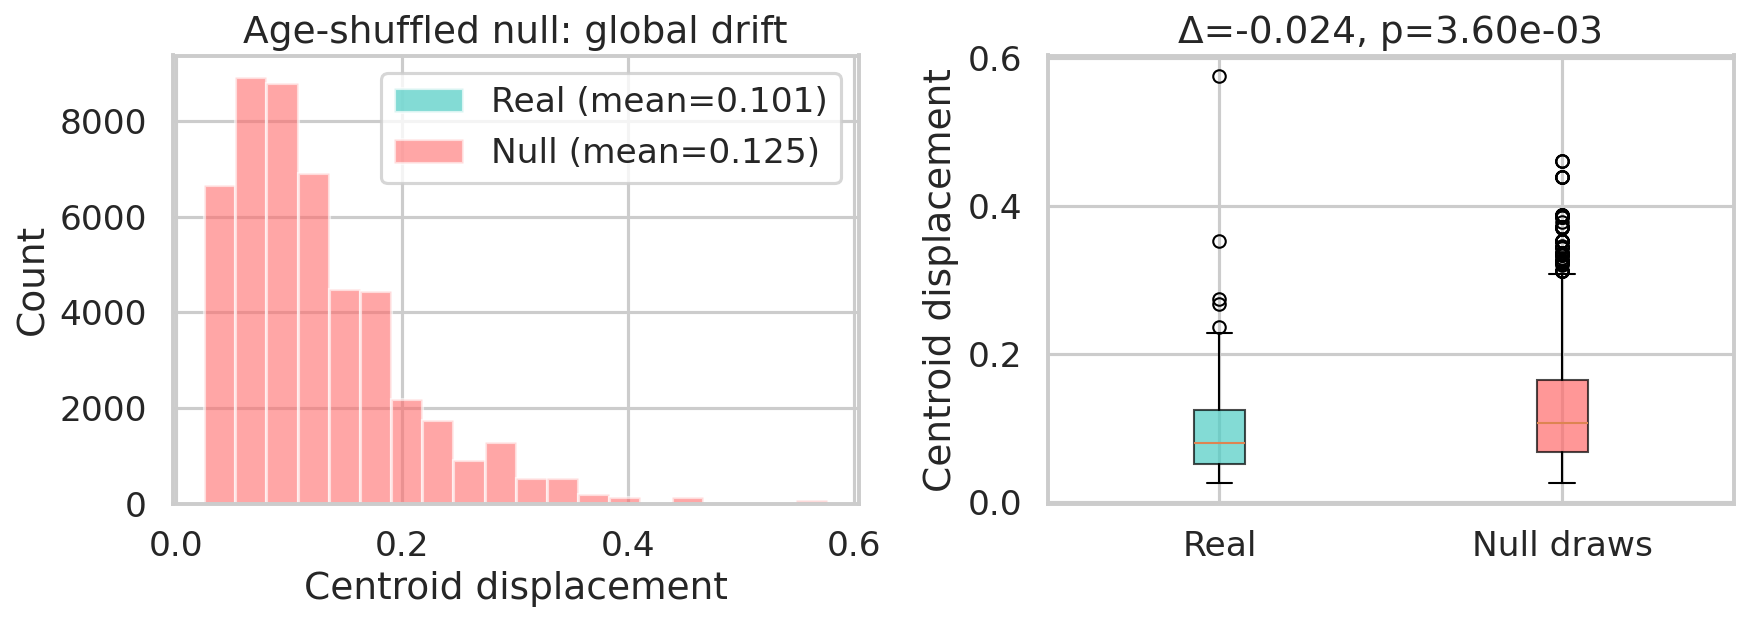

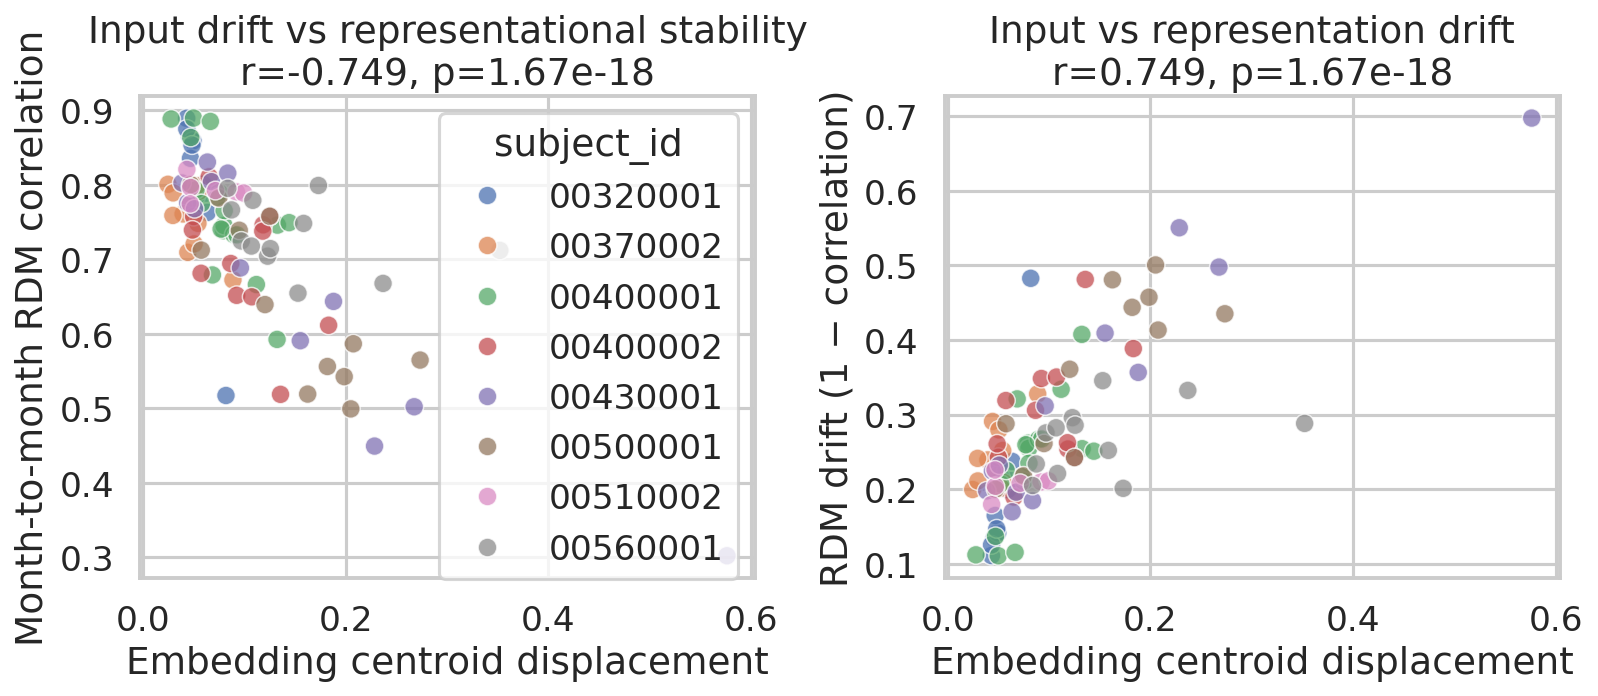

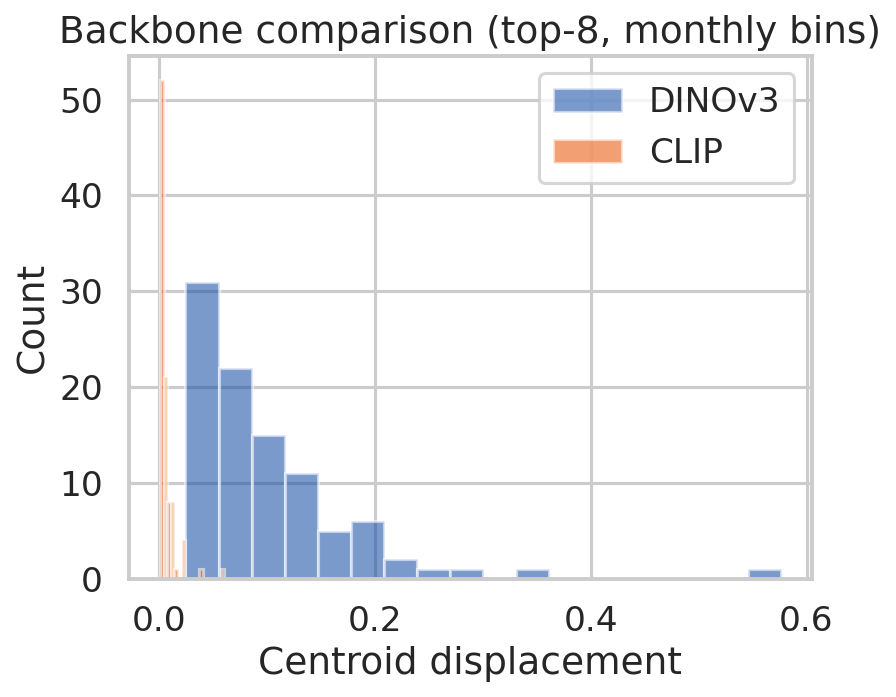

In [3]:
import json
from pathlib import Path
from IPython.display import display, Image

RES = Path("embedding_drift_exploration/results")
FIG = Path("embedding_drift_exploration/figures")
TAG = "dinov3_valid129_bin1_max256_top8"

null = json.loads((RES / f"null_age_shuffle_summary_{TAG}.json").read_text())
rdm = pd.read_csv(RES / f"drift_rdm_correlations_{TAG}.csv")
backbone = pd.read_csv(RES / "backbone_comparison_monthly_top8.csv")
bins = pd.read_csv(RES / "bin_width_comparison_top8_dinov3.csv")

print("Age-shuffled null (global):")
for k in ("real_mean", "null_mean", "difference_real_minus_null", "ttest_p", "cohens_d"):
    print(f"  {k}: {null[k]:.4f}" if isinstance(null[k], float) else f"  {k}: {null[k]}")

display(rdm)
display(backbone)
display(bins)

for fig in ["null_age_shuffle", "drift_vs_rdm", "backbone_comparison_monthly_top8"]:
    matches = list(FIG.glob(f"{fig}*{TAG.split('_top')[0]}*")) + list(FIG.glob(f"{fig}*"))
    seen = set()
    for p in sorted(matches):
        if p.name in seen:
            continue
        seen.add(p.name)
        if p.suffix == ".png" and fig in p.name:
            display(Image(filename=str(p)))
            break

## Pre-rendered trajectory figures

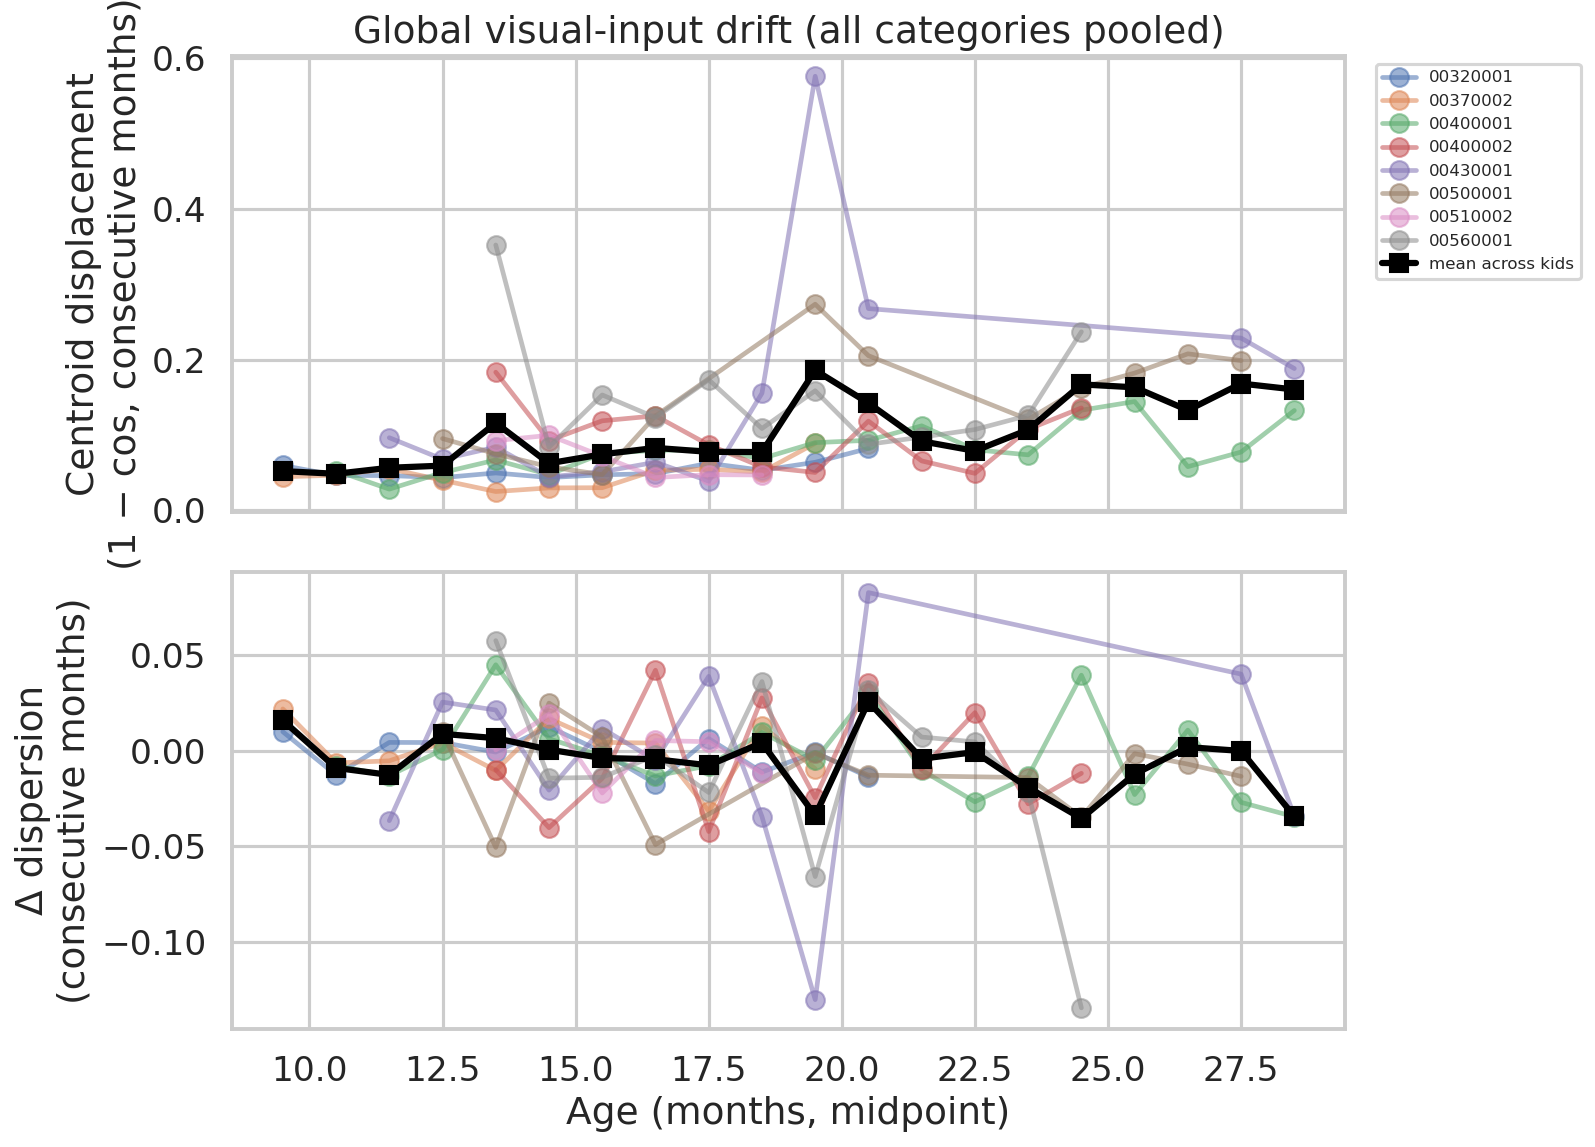

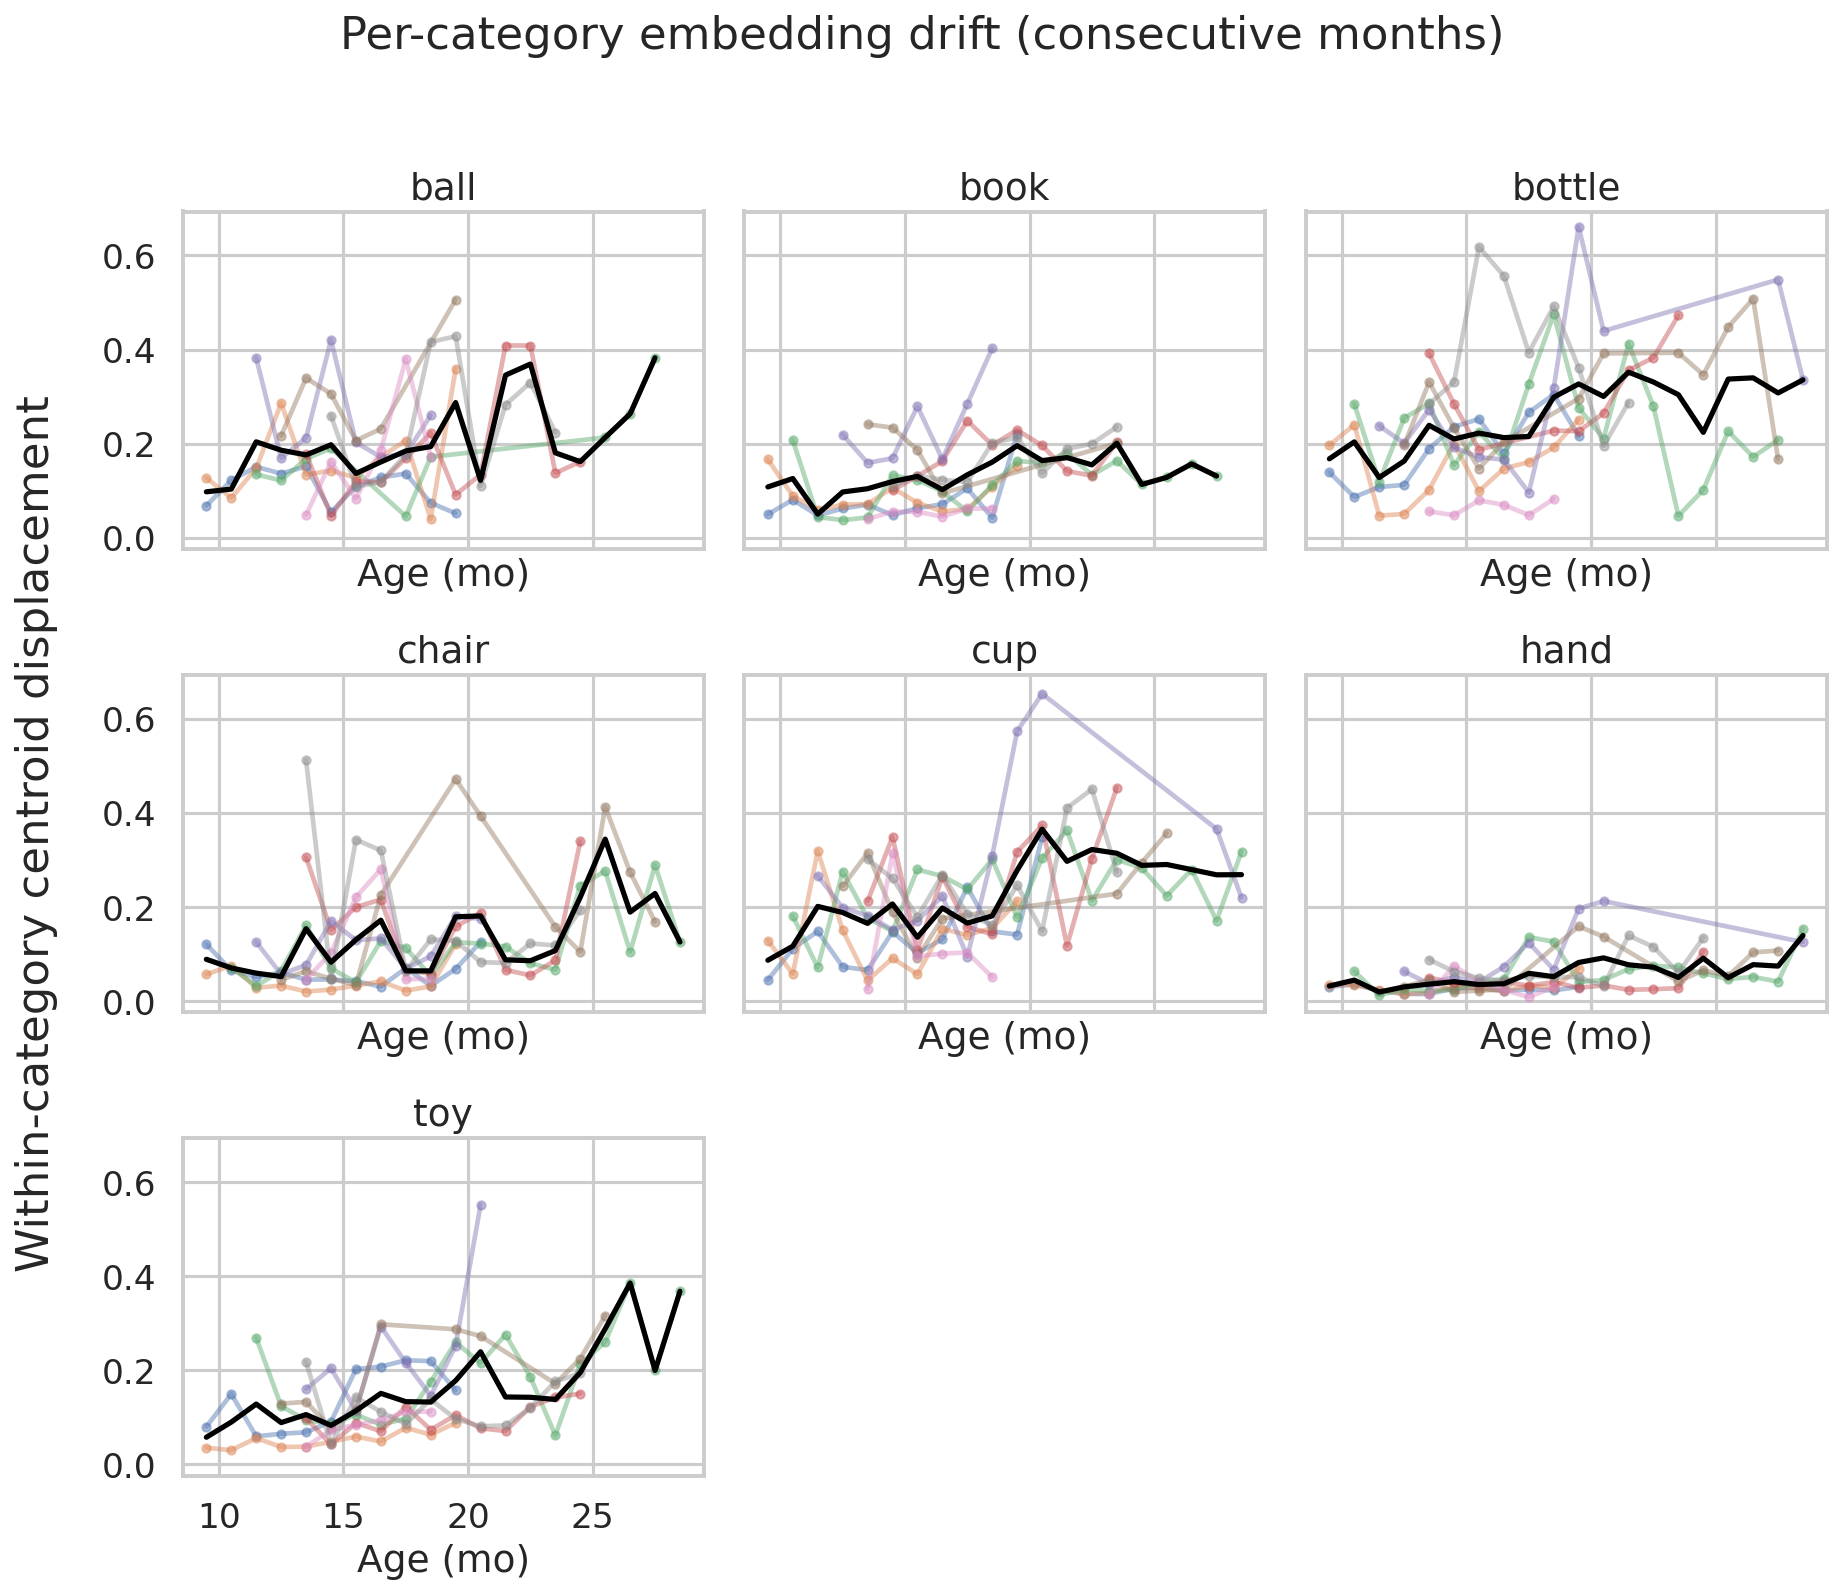

In [4]:
from IPython.display import Image, display

for name in [
    f"global_drift_trajectories_{TAG}.png",
    f"category_drift_trajectories_{TAG}.png",
]:
    p = FIG / name
    if p.exists():
        display(Image(filename=str(p)))